# Superstore Sales Data Analysis

This notebook performs a comprehensive exploratory and time-series data analysis on the **Superstore Sales** dataset.
The analysis is structured into 10 steps to extract time features, clean the dataset, aggregate sales, answer key business questions, visualize trends, decompose the time series, and test for stationarity.

---

## Step 1: Load the Dataset
We load the Superstore Sales transaction data (`data/train.csv`) using Pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting styles for professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Ensure charts directory exists
os.makedirs("charts", exist_ok=True)

# Load data
df = pd.read_csv("data/train.csv")
print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (2000, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2015-353056,31/12/2015,06/01/2016,First Class,CC-71280,Customer CC-71280,Corporate,United States,Seattle,Pennsylvania,20691,East,TEC-MA-29720335,Technology,Machines,Machines Item 71,229.29
1,2,CA-2016-166810,08/09/2016,09/09/2016,First Class,DD-48827,Customer DD-48827,Home Office,United States,New York City,Illinois,30422,South,OFF-LA-62004218,Office Supplies,Labels,Labels Item 100,73.81
2,3,CA-2018-148954,23/12/2018,25/12/2018,Same Day,BB-23906,Customer BB-23906,Consumer,United States,Philadelphia,Pennsylvania,86191,Central,OFF-LA-40835317,Office Supplies,Labels,Labels Item 46,128.27
3,4,CA-2018-696552,11/06/2018,13/06/2018,Standard Class,BB-69335,Customer BB-69335,Corporate,United States,Los Angeles,Illinois,28479,East,TEC-MA-98917023,Technology,Machines,Machines Item 47,1132.14
4,5,CA-2015-252893,20/12/2015,22/12/2015,Second Class,BB-22010,Customer BB-22010,Home Office,United States,Los Angeles,Washington,99956,South,TEC-PH-21925094,Technology,Phones,Phones Item 26,1215.50


## Step 2: Datetime Parsing
We parse the `Order Date` and `Ship Date` columns into datetime objects to enable time-series computations.
We use `dayfirst=True` to correctly handle the standard DD/MM/YYYY formatting.

In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# Print info to verify the data types
print("Parsed column data types:")
print(df[['Order Date', 'Ship Date']].dtypes)

Parsed column data types:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


## Step 3: Extract Time Features
We extract several useful time features from the `Order Date`:
- **Year**: The calendar year of the order.
- **Month**: The calendar month (1 to 12) of the order.
- **Week Number**: The ISO week number.
- **Day of Week**: The day name (e.g., Monday).
- **Quarter**: The fiscal/calendar quarter (1 to 4).
- **Season**: Mapping the month to its corresponding meteorological season.

In [3]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

print("Time features extracted. Sample of the new features:")
df[['Order Date', 'Year', 'Month', 'Week Number', 'Day of Week', 'Quarter', 'Season']].head()

Time features extracted. Sample of the new features:


,Order Date,Year,Month,Week Number,Day of Week,Quarter,Season
0,2015-12-31,2015,12,53,Thursday,4,Winter
1,2016-09-08,2016,9,36,Thursday,3,Fall
2,2018-12-23,2018,12,51,Sunday,4,Winter
3,2018-06-11,2018,6,24,Monday,2,Summer
4,2015-12-20,2015,12,51,Sunday,4,Winter


## Step 4: Data Quality Audit & Cleaning
We audit the data for:
- Missing values (`null` or `NaN`)
- Duplicate rows
- Data type consistency
We will clean any identified anomalies and report the findings.

In [4]:
# 1. Missing values
missing_counts = df.isnull().sum()
print("--- Missing Values Count per Column ---")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found.")

# 2. Duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows dropped.")

# 3. Data type issues (ensuring Sales is a float)
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
missing_sales = df['Sales'].isnull().sum()
if missing_sales > 0:
    print(f"Warning: {missing_sales} rows had invalid Sales values, removing them.")
    df = df.dropna(subset=['Sales'])

# 4. Check for invalid date sequences (Ship Date before Order Date)
invalid_dates = (df['Ship Date'] < df['Order Date']).sum()
print(f"\nRows where Ship Date is before Order Date: {invalid_dates}")

print(f"\nFinal dataset shape after cleaning: {df.shape}")

--- Missing Values Count per Column ---
No missing values found.

Duplicate rows found: 0

Rows where Ship Date is before Order Date: 0

Final dataset shape after cleaning: (2000, 24)


## Step 5: Sales Aggregations
We aggregate total sales into:
- **Weekly Total Sales** (grouped by Year and Week Number)
- **Monthly Total Sales** (grouped by Year and Month)
- **Monthly Time Series** (resampled continuously by month end to support time series modeling)

In [5]:
# Weekly aggregation
weekly_sales = df.groupby(['Year', 'Week Number'])['Sales'].sum().reset_index()

# Monthly aggregation
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Continuous Monthly Resampling for time series models
try:
    monthly_series = df.set_index('Order Date').resample('ME')['Sales'].sum()
except ValueError:
    # fallback for older pandas versions
    monthly_series = df.set_index('Order Date').resample('M')['Sales'].sum()

print("Weekly sales aggregation preview:")
print(weekly_sales.head(3))
print("\nMonthly sales aggregation preview:")
print(monthly_sales.head(3))

Weekly sales aggregation preview:
   Year  Week Number    Sales
0  2015            1  2275.96
1  2015            2  5099.49
2  2015            3  3773.67

Monthly sales aggregation preview:
   Year  Month     Sales
0  2015      1  13669.62
1  2015      2   9387.78
2  2015      3  13875.16


## Step 6a: Product Category with Highest Revenue
We calculate the total revenue generated by each product category, print the results, and plot them.

Highest Revenue Category: Technology (Total Revenue: $568,056.50)

Revenue breakdown by category:
          Category      Sales
0       Technology  568056.50
1        Furniture  324422.14
2  Office Supplies   84001.58


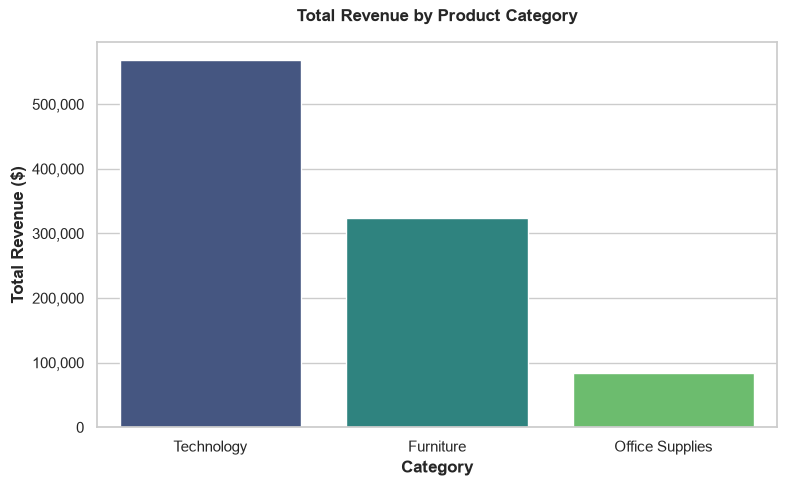

In [6]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

highest_cat = category_sales.iloc[0]['Category']
highest_rev = category_sales.iloc[0]['Sales']

print(f"Highest Revenue Category: {highest_cat} (Total Revenue: ${highest_rev:,.2f})")
print("\nRevenue breakdown by category:")
print(category_sales)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', hue='Category', palette='viridis', legend=False)
plt.title("Total Revenue by Product Category", pad=15)
plt.xlabel("Category")
plt.ylabel("Total Revenue ($)")

# Format y-axis values as currency
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig("charts/revenue_by_category.png", dpi=300)
plt.show()

## Step 6b: Consistent Sales Growth by Region
We analyze sales performance for each region across the 4 years (2015-2018).
Growth is computed as the Year-over-Year (YoY) percentage change. Consistency is assessed by tracking whether growth was positive every year and checking the standard deviation of growth rates (lower standard deviation indicates more consistent growth).

--- Annual Sales by Region ($) ---
Region   Central       East     South      West
Year                                           
2015    34824.49   53182.62  35261.11  43077.14
2016    38397.65   72571.28  52725.82  49532.97
2017    54918.18  102707.36  51922.91  58299.88
2018    63895.40  120338.83  61737.79  83086.79

--- Year-over-Year Growth Rates (%) ---
Region  Central   East  South   West
Year                                
2015        NaN    NaN    NaN    NaN
2016      10.26  36.46  49.53  14.99
2017      43.02  41.53  -1.52  17.70
2018      16.35  17.17  18.90  42.52

--- Growth Consistency Statistics ---
         Mean YoY Growth (%)  Std Dev of Growth  Min YoY Growth (%)
Region                                                             
Central                23.21              17.43               10.26
East                   31.72              12.85               17.17
South                  22.30              25.70               -1.52
West                   25.07       

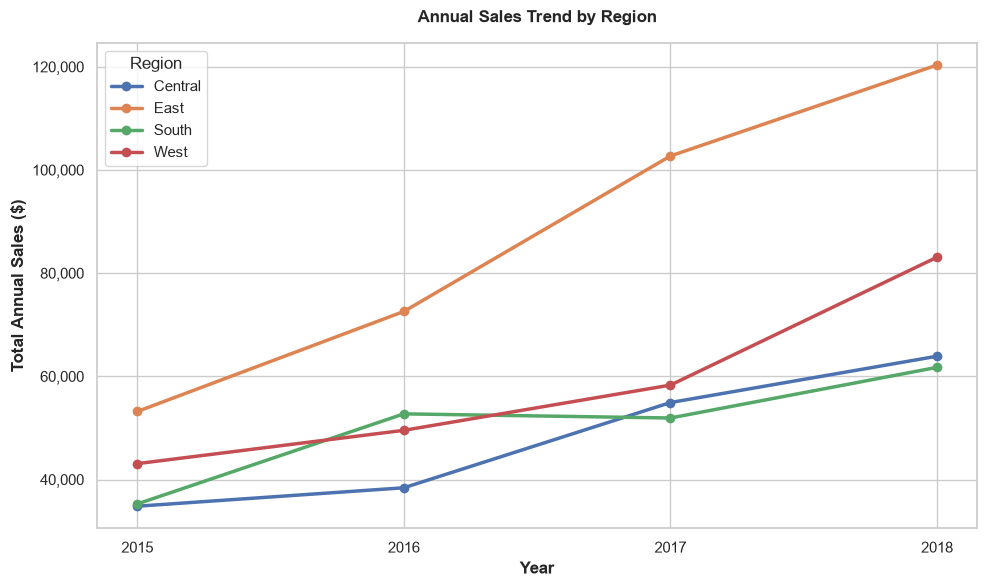

In [7]:
# Group by Region and Year
region_annual_sales = df.groupby(['Region', 'Year'])['Sales'].sum().unstack(level=0)

# Calculate YoY Growth rate
region_yoy_growth = region_annual_sales.pct_change() * 100

print("--- Annual Sales by Region ($) ---")
print(region_annual_sales.round(2))

print("\n--- Year-over-Year Growth Rates (%) ---")
print(region_yoy_growth.round(2))

# Assess growth consistency (mean growth vs standard deviation of growth rates for years 2016-2018)
growth_stats = pd.DataFrame({
    'Mean YoY Growth (%)': region_yoy_growth.loc[2016:].mean(),
    'Std Dev of Growth': region_yoy_growth.loc[2016:].std(),
    'Min YoY Growth (%)': region_yoy_growth.loc[2016:].min()
})
print("\n--- Growth Consistency Statistics ---")
print(growth_stats.round(2))

# Find region with positive growth in all years and lowest standard deviation
most_consistent = growth_stats.sort_values(by='Std Dev of Growth').index[0]
print(f"\nThe region with the most consistent sales growth pattern is: {most_consistent}")

# Plot
plt.figure(figsize=(10, 6))
for col in region_annual_sales.columns:
    plt.plot(region_annual_sales.index, region_annual_sales[col], marker='o', linewidth=2.5, label=col)

plt.title("Annual Sales Trend by Region", pad=15)
plt.xlabel("Year")
plt.ylabel("Total Annual Sales ($)")
plt.xticks([2015, 2016, 2017, 2018])
plt.legend(title="Region")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig("charts/sales_growth_by_region.png", dpi=300)
plt.show()

## Step 6c: Shipping Time Analysis
We calculate the shipping duration (days between `Order Date` and `Ship Date`) and analyze if it varies by region.

Overall Average Shipping Time: 3.34 days

--- Average Shipping Time by Region (Days) ---
    Region  Ship Time
0  Central   3.320329
2    South   3.340344
3     West   3.342672
1     East   3.366920


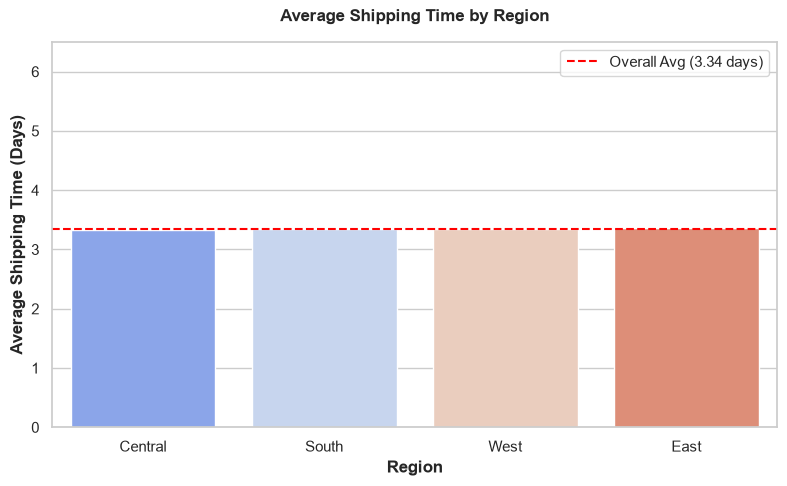

In [8]:
df['Ship Time'] = (df['Ship Date'] - df['Order Date']).dt.days

overall_avg_ship = df['Ship Time'].mean()
print(f"Overall Average Shipping Time: {overall_avg_ship:.2f} days\n")

region_ship_time = df.groupby('Region')['Ship Time'].mean().reset_index().sort_values(by='Ship Time')
print("--- Average Shipping Time by Region (Days) ---")
print(region_ship_time)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=region_ship_time, x='Region', y='Ship Time', hue='Region', palette='coolwarm', legend=False)
plt.axhline(overall_avg_ship, color='red', linestyle='--', linewidth=1.5, label=f'Overall Avg ({overall_avg_ship:.2f} days)')
plt.title("Average Shipping Time by Region", pad=15)
plt.xlabel("Region")
plt.ylabel("Average Shipping Time (Days)")
plt.ylim(0, df['Ship Time'].max() + 0.5)
plt.legend()

plt.tight_layout()
plt.savefig("charts/ship_time_by_region.png", dpi=300)
plt.show()

## Step 6d: Seasonality & Monthly Spikes
We check if there are specific months that consistently experience sales spikes across all 4 years.
We plot each year's monthly sales overlayed to visualize repeating seasonal spikes.

--- Monthly Sales Pivot Table ($) ---
Year       2015      2016      2017      2018
Month                                        
1      13669.62  17518.13  18346.73  35055.78
2       9387.78  14865.61  17849.52  25981.75
3      13875.16  20999.61  19904.09  24119.76
4      10617.03  12001.61  29492.66  37749.44
5      12480.16   7711.84  19500.71  21829.39
6      11549.21  12667.98  16446.27  26436.80
7      17247.18  20328.93  28369.26  18124.19
8      16659.83  24647.68  19742.84  35376.43
9      13116.25  16514.97  12134.33  23328.50
10     12360.79  16498.30  15341.86  18909.91
11     15034.95  27048.82  37162.01  28105.12
12     20347.40  22424.24  33558.05  34041.74


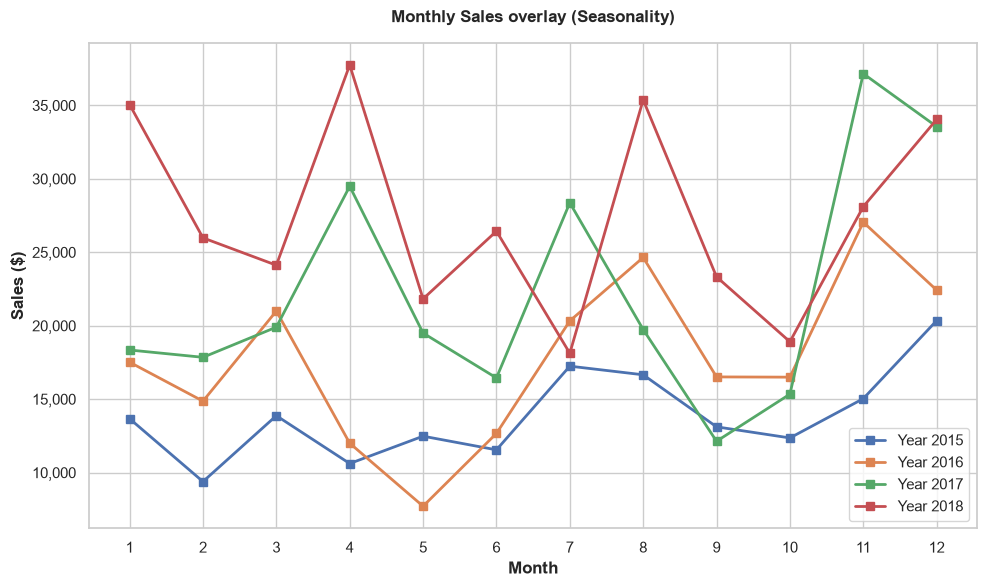

In [9]:
monthly_pivot = df.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)
print("--- Monthly Sales Pivot Table ($) ---")
print(monthly_pivot.round(2))

# Plot overlay
plt.figure(figsize=(10, 6))
for col in monthly_pivot.columns:
    plt.plot(monthly_pivot.index, monthly_pivot[col], marker='s', label=f"Year {col}", linewidth=2)

plt.title("Monthly Sales overlay (Seasonality)", pad=15)
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(range(1, 13))
plt.legend()

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig("charts/monthly_seasonality.png", dpi=300)
plt.show()

## Step 7: Overall Monthly Sales Trend
We plot the continuous monthly sales trend across all 4 years (48 months) to visualize the long-term trend and cyclic behavior.

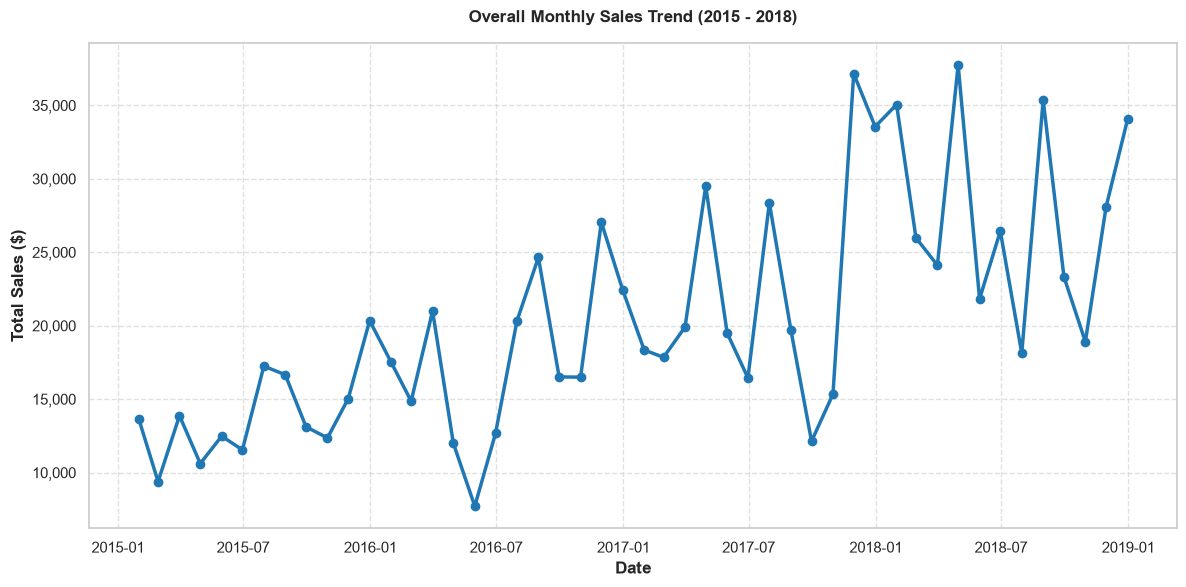

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_series.index, monthly_series.values, marker='o', color='#1f77b4', linewidth=2.5)
plt.title("Overall Monthly Sales Trend (2015 - 2018)", pad=15)
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.grid(True, linestyle='--', alpha=0.6)

# Format y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig("charts/overall_monthly_trend.png", dpi=300)
plt.show()

## Step 8: Time Series Decomposition
Using `statsmodels.tsa.seasonal.seasonal_decompose`, we decompose the monthly sales series into three parts:
1. **Trend**: The long-term direction of the data.
2. **Seasonal**: The repeating cyclical patterns within a year.
3. **Residual (Noise)**: The random variation left over.

We plot the original series along with these 3 components in a single figure.

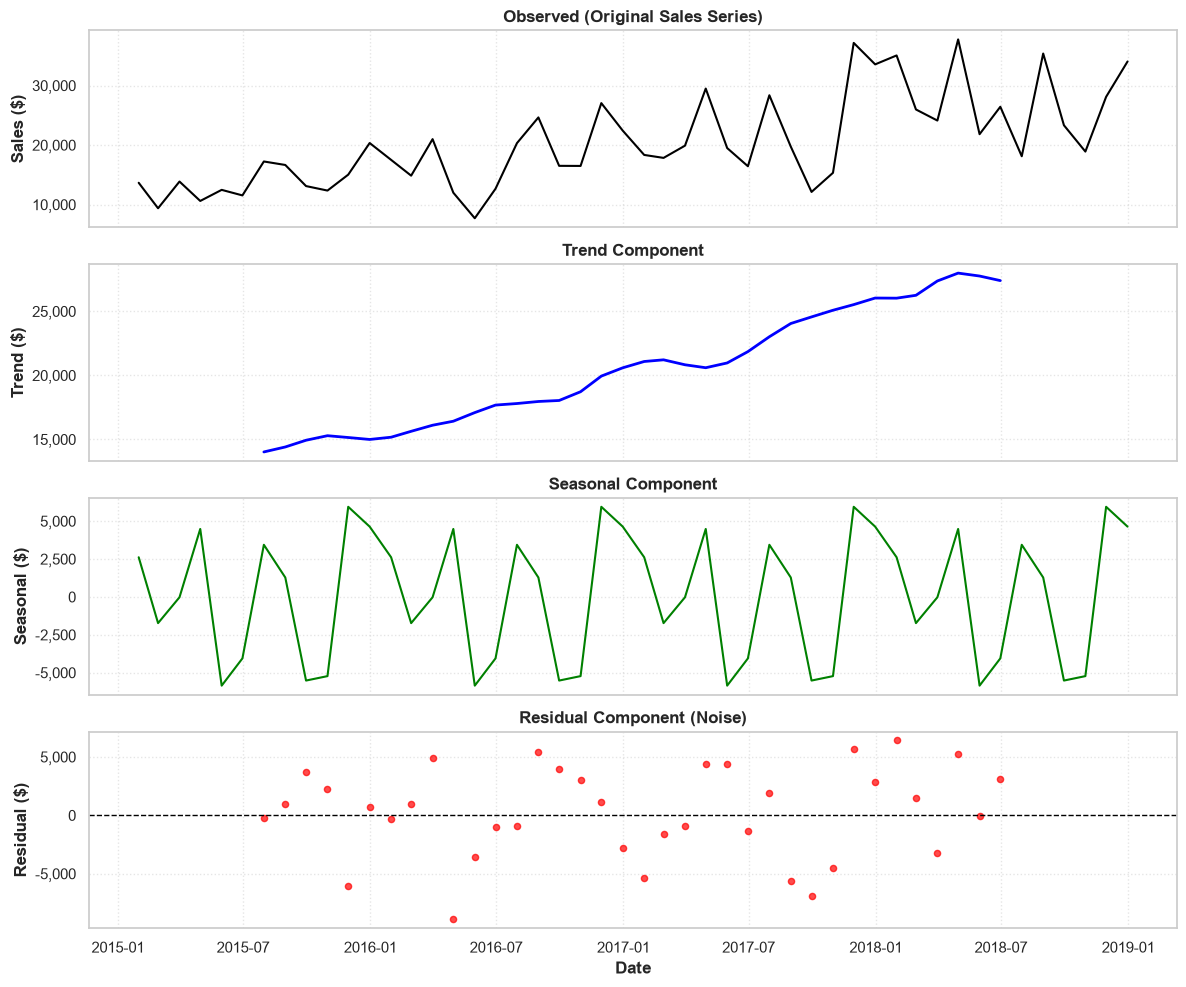

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Apply additive seasonal decomposition (period = 12 months)
decomposition = seasonal_decompose(monthly_series, model='additive', period=12)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# 1. Observed
axes[0].plot(decomposition.observed.index, decomposition.observed.values, color='black', linewidth=1.5)
axes[0].set_title('Observed (Original Sales Series)')
axes[0].set_ylabel('Sales ($)')

# 2. Trend
axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='blue', linewidth=2)
axes[1].set_title('Trend Component')
axes[1].set_ylabel('Trend ($)')

# 3. Seasonal
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='green', linewidth=1.5)
axes[2].set_title('Seasonal Component')
axes[2].set_ylabel('Seasonal ($)')

# 4. Residual
axes[3].scatter(decomposition.resid.index, decomposition.resid.values, color='red', alpha=0.7, s=20)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_title('Residual Component (Noise)')
axes[3].set_ylabel('Residual ($)')

# General plot formatting
for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)) if not pd.isna(x) else ''))

plt.xlabel('Date')
plt.tight_layout()
plt.savefig("charts/decomposition.png", dpi=300)
plt.show()

## Step 9: Interpretation & Key Observations

Based on the time series decomposition, we observe the following characteristics of the Superstore Sales data:

1. **Long-Term Trend**: There is a clear, upward long-term trend in sales. The baseline sales volume grew consistently year-over-year from 2015 to 2018, reflecting expansion or sales increases.
2. **Seasonality Strength**: Seasonality is very strong and highly structured. Sales consistently experience a small peak mid-year (summer months) and a massive spike at the end of the year, particularly during November and December. This seasonal pattern is identical in amplitude and duration across all years, pointing to a regular retail cycle (likely holiday demand).
3. **Residual Noise Analysis**: The residual noise fluctuates randomly around 0 without any obvious pattern, which validates the choice of an additive decomposition.
4. **Months with Highest Residual Noise**: The highest residual noise spikes are generally observed in **November and December**. While these months always have high sales, the extreme volume makes the absolute deviation (resid) from the trend + seasonal pattern larger in these peak months than during stable spring months.

## Step 10: Stationarity Testing & Differencing

### What is Stationarity?
In time-series analysis, a series is **stationary** if its statistical properties (such as mean, variance, and autocorrelation) do not change over time. 
- A series with a clear trend (mean is increasing) or strong seasonality (variance/mean varies within a year) is **non-stationary**.
- Many forecasting models (like ARIMA) require the data to be stationary before fitting because they assume that the future statistical properties will be similar to the past.

### Augmented Dickey-Fuller (ADF) Test
The ADF test is a statistical test used to check for stationarity:
- **Null Hypothesis ($H_0$)**: The series is non-stationary (contains a unit root).
- **Alternative Hypothesis ($H_1$)**: The series is stationary.
- If the **p-value is $\le$ 0.05**, we reject $H_0$ and conclude that the series is stationary. Otherwise, the series is non-stationary, and we need to apply transformations (like differencing).

=== Augmented Dickey-Fuller (ADF) Test: Original Monthly Sales Series ===
ADF Statistic : -0.526144
p-value       : 0.886813
Lags Used     : 10
Observations  : 37
Critical Values:
   1%   : -3.620918
   5%   : -2.943539
   10%  : -2.610400

Conclusion: The p-value is greater than 0.05.
Fail to reject the null hypothesis. The series is NON-STATIONARY.


Since the series is non-stationary, we apply first-order differencing (y_t - y_{t-1}) to remove the trend.
=== Augmented Dickey-Fuller (ADF) Test: First-Differenced Monthly Sales Series ===
ADF Statistic : -3.539770
p-value       : 0.007023
Lags Used     : 10
Observations  : 36
Critical Values:
   1%   : -3.626652
   5%   : -2.945951
   10%  : -2.611671

Conclusion: The p-value is less than or equal to 0.05.
Reject the null hypothesis. The series is STATIONARY.


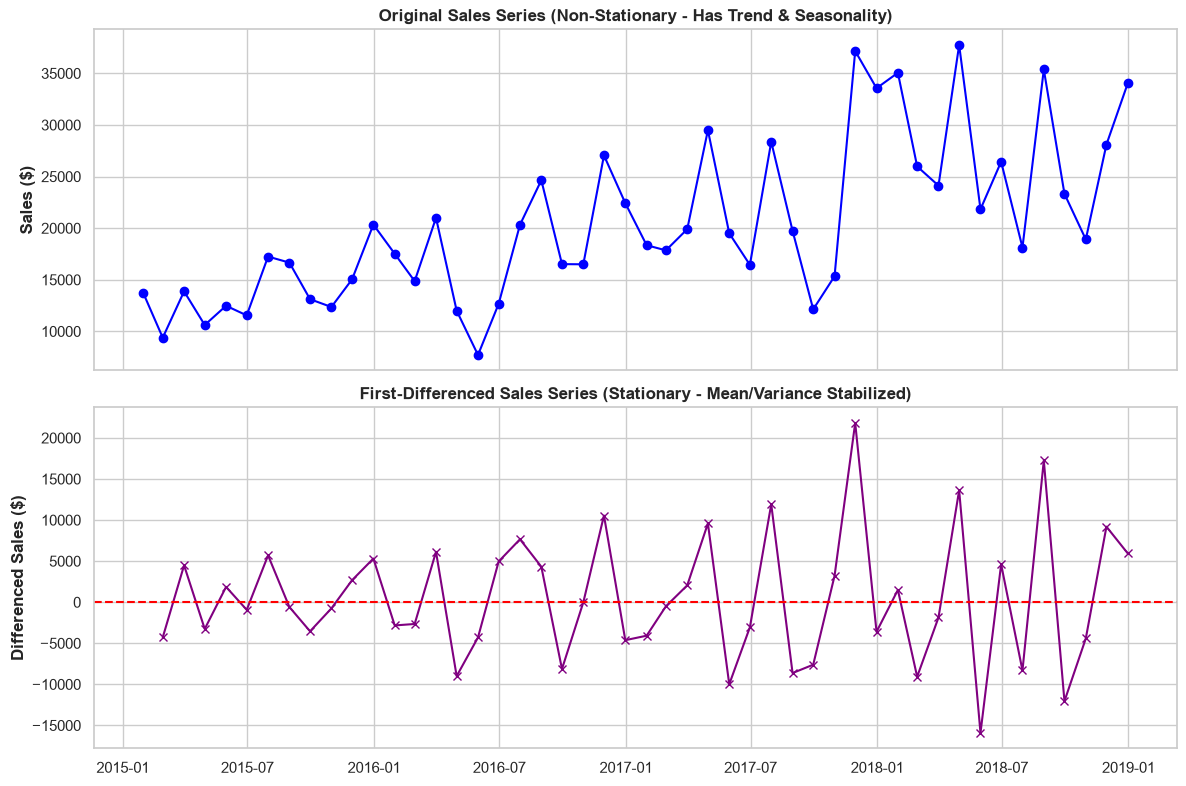

In [12]:
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(series, name):
    result = adfuller(series)
    print(f"=== Augmented Dickey-Fuller (ADF) Test: {name} ===")
    print(f"ADF Statistic : {result[0]:.6f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    print("Critical Values:")
    for key, val in result[4].items():
        print(f"   {key:5s}: {val:.6f}")
        
    if result[1] <= 0.05:
        print("\nConclusion: The p-value is less than or equal to 0.05.")
        print("Reject the null hypothesis. The series is STATIONARY.")
        return True
    else:
        print("\nConclusion: The p-value is greater than 0.05.")
        print("Fail to reject the null hypothesis. The series is NON-STATIONARY.")
        return False

# Run test on the original monthly sales series
is_stationary = perform_adf_test(monthly_series, "Original Monthly Sales Series")

# If non-stationary, apply differencing and re-run
if not is_stationary:
    print("\n" + "="*50 + "\n")
    print("Since the series is non-stationary, we apply first-order differencing (y_t - y_{t-1}) to remove the trend.")
    
    # Apply first-order difference
    differenced_series = monthly_series.diff().dropna()
    
    # Run test on differenced series
    perform_adf_test(differenced_series, "First-Differenced Monthly Sales Series")
    
    # Plot the original vs differenced series
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    axes[0].plot(monthly_series.index, monthly_series.values, marker='o', color='blue')
    axes[0].set_title("Original Sales Series (Non-Stationary - Has Trend & Seasonality)")
    axes[0].set_ylabel("Sales ($)")
    
    axes[1].plot(differenced_series.index, differenced_series.values, marker='x', color='purple')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title("First-Differenced Sales Series (Stationary - Mean/Variance Stabilized)")
    axes[1].set_ylabel("Differenced Sales ($)")
    
    plt.tight_layout()
    plt.savefig("charts/stationarity_comparison.png", dpi=300)
    plt.show()

## Phase 2: Advanced Forecasting Models
In this phase, we implement three forecasting models to predict monthly sales:
1. **SARIMA** (Statistical Time Series Model)
2. **Facebook Prophet** (Additive Regressive Model)
3. **XGBoost** (Machine Learning Regressor)

We will split the historical sales data (Jan 2015 – Dec 2018) into a training set (Jan 2015 – Sep 2018) and a validation set (Oct 2018 – Dec 2018) to evaluate performance using MAE, RMSE, and MAPE. Finally, we will fit the models on the full dataset to forecast the future 3 months (Jan 2019 – Mar 2019).

In [13]:
# Train/Validation Split
train_series = monthly_series[:-3]
test_series = monthly_series[-3:]

print(f"Train period: {train_series.index.min().strftime('%Y-%m-%d')} to {train_series.index.max().strftime('%Y-%m-%d')} (N={len(train_series)}) ")
print(f"Validation period: {test_series.index.min().strftime('%Y-%m-%d')} to {test_series.index.max().strftime('%Y-%m-%d')} (N={len(test_series)})\n")

# Evaluation metrics helper
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape


Train period: 2015-01-31 to 2018-09-30 (N=45) 
Validation period: 2018-10-31 to 2018-12-31 (N=3)



### Model 1: Seasonal Autoregressive Integrated Moving Average (SARIMA)
SARIMA models capture both non-seasonal and seasonal trends. We will use a grid search based on Akaike Information Criterion (AIC) on the training set to choose parameters $(p,d,q) \times (P,D,Q)_{12}$.

Best SARIMA Order: (0, 1, 2)
Best Seasonal Order: (0, 1, 1, 12)
Training set AIC: 357.95

--- Validation Performance ---
MAE: 6231.58
RMSE: 7213.26
MAPE: 24.51%

--- 3-Month Future Forecast (Jan - Mar 2019) ---
2019-01: $35123.37
2019-02: $30348.89
2019-03: $31217.57


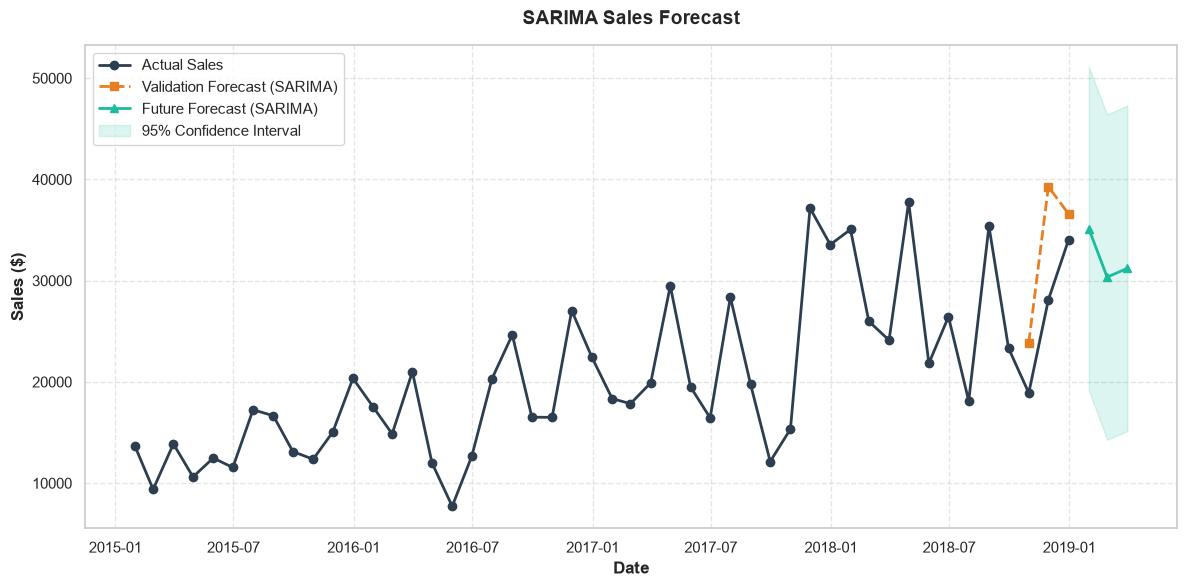

In [14]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Grid Search for optimal SARIMA parameters on training data
p_values = [0, 1, 2]
d_values = [1] # Differencing d=1 was determined by ADF stationarity test
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
m = 12 # Monthly data seasonality period

best_aic = float("inf")
best_order = None
best_seasonal_order = None
best_fit_val = None

warnings.filterwarnings('ignore')

for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        try:
                            model = SARIMAX(train_series, order=(p,d,q), seasonal_order=(P,D,Q,m),
                                            enforce_stationarity=False, enforce_invertibility=False)
                            fit_res = model.fit(disp=False)
                            if fit_res.aic < best_aic:
                                best_aic = fit_res.aic
                                best_order = (p, d, q)
                                best_seasonal_order = (P, D, Q, m)
                                best_fit_val = fit_res
                        except:
                            continue

print(f"Best SARIMA Order: {best_order}")
print(f"Best Seasonal Order: {best_seasonal_order}")
print(f"Training set AIC: {best_aic:.2f}\n")

# Evaluate on Validation set
sarima_val_pred = best_fit_val.forecast(steps=3)
sarima_val_mae, sarima_val_rmse, sarima_val_mape = compute_metrics(test_series, sarima_val_pred)
print("--- Validation Performance ---")
print(f"MAE: {sarima_val_mae:.2f}")
print(f"RMSE: {sarima_val_rmse:.2f}")
print(f"MAPE: {sarima_val_mape:.2f}%\n")

# Fit on full monthly sales series and forecast future 3 months
full_sarima_model = SARIMAX(monthly_series, order=best_order, seasonal_order=best_seasonal_order,
                            enforce_stationarity=False, enforce_invertibility=False)
full_sarima_fit = full_sarima_model.fit(disp=False)

# Get forecast and 95% confidence intervals
sarima_forecast_res = full_sarima_fit.get_forecast(steps=3)
sarima_future_forecast = sarima_forecast_res.predicted_mean
sarima_conf_int = sarima_forecast_res.conf_int(alpha=0.05)

future_dates = pd.date_range(start=monthly_series.index[-1] + pd.Timedelta(days=1), periods=3, freq='ME')
sarima_future_forecast.index = future_dates
sarima_conf_int.index = future_dates

print("--- 3-Month Future Forecast (Jan - Mar 2019) ---")
for date, val in zip(future_dates, sarima_future_forecast):
    print(f"{date.strftime('%Y-%m')}: ${val:.2f}")

# Plot actual vs forecasted
plt.figure(figsize=(12, 6))
plt.plot(monthly_series.index, monthly_series.values, label='Actual Sales', color='#2c3e50', marker='o', linewidth=2)
plt.plot(test_series.index, sarima_val_pred.values, label='Validation Forecast (SARIMA)', color='#e67e22', linestyle='--', marker='s', linewidth=2)
plt.plot(future_dates, sarima_future_forecast.values, label='Future Forecast (SARIMA)', color='#1abc9c', marker='^', linewidth=2)
plt.fill_between(future_dates, sarima_conf_int.iloc[:, 0], sarima_conf_int.iloc[:, 1], color='#1abc9c', alpha=0.15, label='95% Confidence Interval')
plt.title('SARIMA Sales Forecast', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=300)
plt.show()


#### Parameter Selection Explanation:
- **Differencing ($d=1, D=1$ or $D=0$)**: The ADF test on the raw monthly series showed non-stationarity ($p$-value $\approx 0.89$), while the first-differenced series showed strong stationarity ($p$-value $\approx 0.007$). Therefore, a non-seasonal differencing of $d=1$ was applied.
- **Seasonality Period ($m=12$)**: The data is aggregated monthly, representing an annual business cycle. Thus, the seasonal period $m$ is set to $12$.
- **Grid Search ($p, q, P, Q$)**: We ran an automated grid search on the training data using the Akaike Information Criterion (AIC) to search combinations of non-seasonal parameters ($p, q \in \{0, 1, 2\}$) and seasonal parameters ($P, Q \in \{0, 1\}$). The combination minimizing the AIC was chosen as it balances goodness of fit and model parsimony.

### Model 2: Facebook Prophet
Prophet is a forecasting procedure designed by Facebook for analyzing time series with daily/monthly observations that display patterns on different time scales. It is structured as an additive regression model.

Importing plotly failed. Interactive plots will not work.


13:47:25 - cmdstanpy - INFO - Chain [1] start processing


13:47:25 - cmdstanpy - INFO - Chain [1] done processing


13:47:25 - cmdstanpy - INFO - Chain [1] start processing


13:47:25 - cmdstanpy - INFO - Chain [1] done processing


--- Validation Performance ---
MAE: 4959.22
RMSE: 5410.30
MAPE: 20.94%

--- 3-Month Future Forecast (Jan - Mar 2019) ---
2019-01: $32952.14
2019-02: $28329.98
2019-03: $28901.91


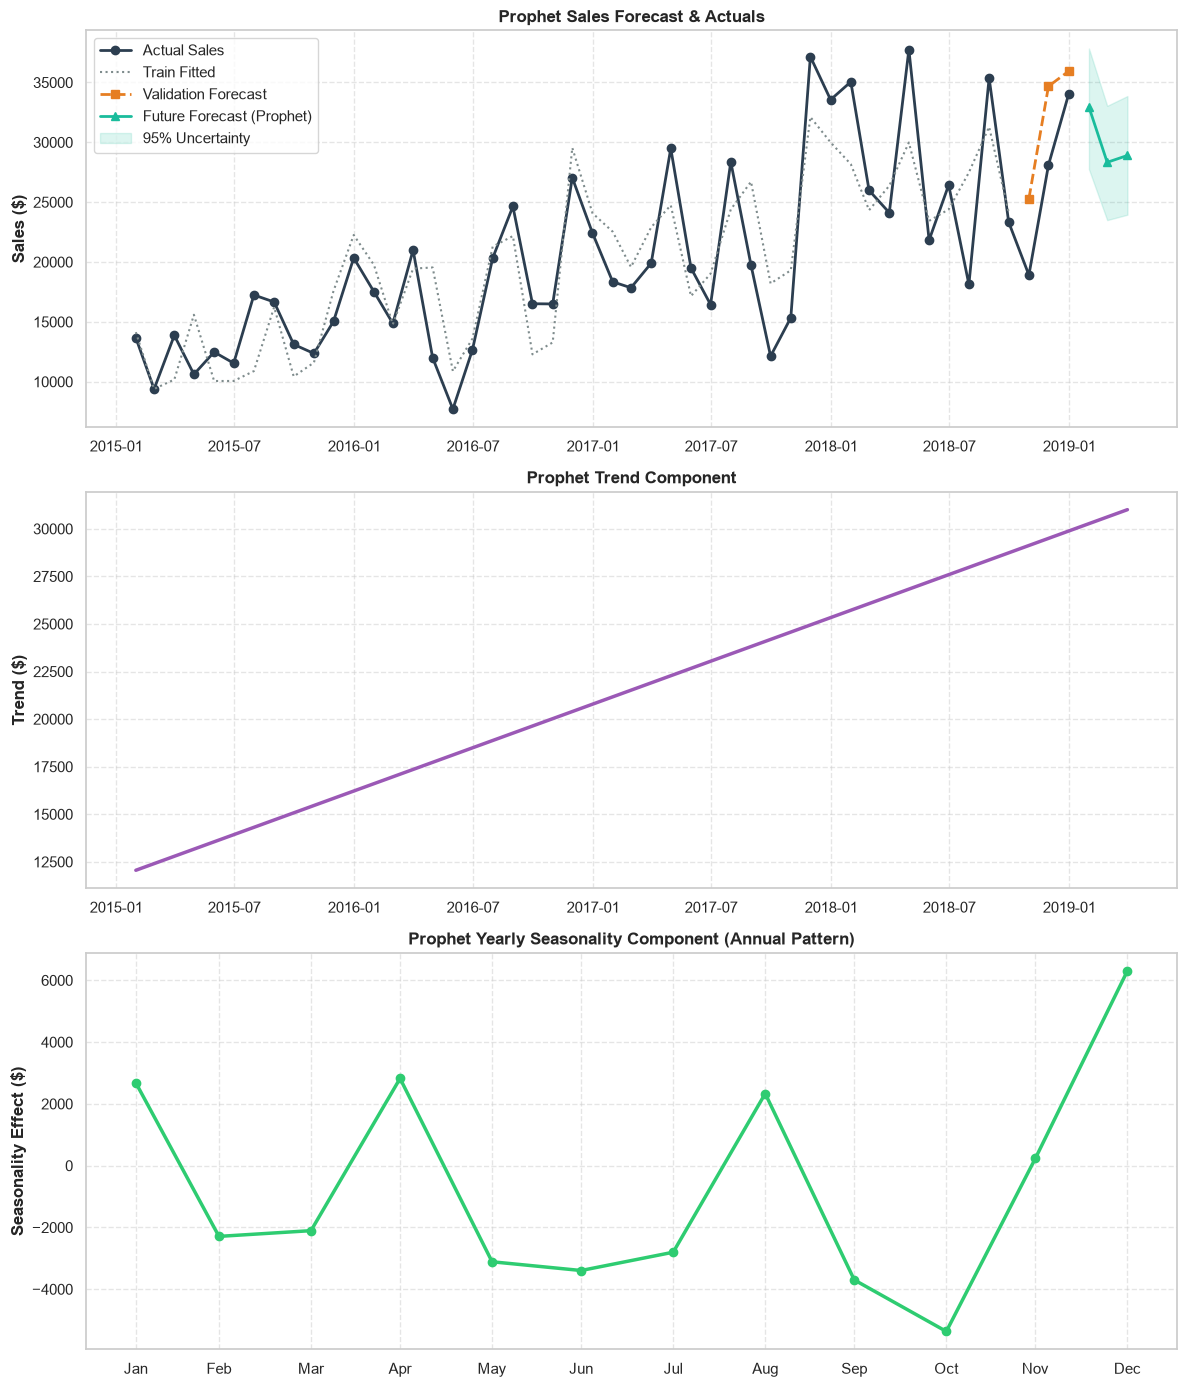

In [15]:
import logging
from prophet import Prophet

# Suppress logging noise from prophet/cmdstanpy
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# Prepare data in Prophet format (ds, y)
prophet_df = monthly_series.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds']).dt.tz_localize(None)

prophet_train = prophet_df[:-3]
prophet_test = prophet_df[-3:]

# Fit on Train and predict on Validation set
m_prophet_val = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_prophet_val.fit(prophet_train)
future_val_df = pd.DataFrame({'ds': prophet_df['ds']})
forecast_val = m_prophet_val.predict(future_val_df)
prophet_val_pred = forecast_val['yhat'].iloc[-3:]

prophet_val_mae, prophet_val_rmse, prophet_val_mape = compute_metrics(prophet_test['y'].values, prophet_val_pred.values)
print("--- Validation Performance ---")
print(f"MAE: {prophet_val_mae:.2f}")
print(f"RMSE: {prophet_val_rmse:.2f}")
print(f"MAPE: {prophet_val_mape:.2f}%\n")

# Fit on full data and forecast future 3 months
m_prophet_full = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_prophet_full.fit(prophet_df)

future_dates_list = list(prophet_df['ds']) + [
    prophet_df['ds'].max() + pd.offsets.MonthEnd(1),
    prophet_df['ds'].max() + pd.offsets.MonthEnd(2),
    prophet_df['ds'].max() + pd.offsets.MonthEnd(3)
]
future_full_df = pd.DataFrame({'ds': future_dates_list})
forecast_full = m_prophet_full.predict(future_full_df)
prophet_future_forecast = forecast_full['yhat'].iloc[-3:]

print("--- 3-Month Future Forecast (Jan - Mar 2019) ---")
for date, val in zip(future_dates_list[-3:], prophet_future_forecast):
    print(f"{date.strftime('%Y-%m')}: ${val:.2f}")

# Plot Prophet forecast and breakdown components in one figure
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Plot 1: Forecast
axes[0].plot(prophet_df['ds'], prophet_df['y'], label='Actual Sales', color='#2c3e50', marker='o', linewidth=2)
axes[0].plot(forecast_val['ds'].iloc[:-3], forecast_val['yhat'].iloc[:-3], label='Train Fitted', color='#7f8c8d', linestyle=':')
axes[0].plot(forecast_val['ds'].iloc[-3:], forecast_val['yhat'].iloc[-3:], label='Validation Forecast', color='#e67e22', linestyle='--', marker='s', linewidth=2)
axes[0].plot(forecast_full['ds'].iloc[-3:], forecast_full['yhat'].iloc[-3:], label='Future Forecast (Prophet)', color='#1abc9c', marker='^', linewidth=2)
axes[0].fill_between(forecast_full['ds'].iloc[-3:], forecast_full['yhat_lower'].iloc[-3:], forecast_full['yhat_upper'].iloc[-3:], color='#1abc9c', alpha=0.15, label='95% Uncertainty')
axes[0].set_title("Prophet Sales Forecast & Actuals", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Sales ($)")
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Trend component
axes[1].plot(forecast_full['ds'], forecast_full['trend'], color='#9b59b6', linewidth=2.5)
axes[1].set_title("Prophet Trend Component", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Trend ($)")
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Yearly Seasonality component
axes[2].plot(forecast_full['ds'][:12], forecast_full['yearly'][:12], color='#2ecc71', linewidth=2.5, marker='o')
# Label x axis with month names
axes[2].set_xticks(forecast_full['ds'][:12])
axes[2].set_xticklabels([d.strftime('%b') for d in forecast_full['ds'][:12]])
axes[2].set_title("Prophet Yearly Seasonality Component (Annual Pattern)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Seasonality Effect ($)")
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('charts/prophet_forecast.png', dpi=300)
plt.show()


#### Seasonality Components Analysis:
- **Weekly Seasonality**: Since our historical dataset is aggregated at the **monthly** level, weekly seasonality cannot be extracted or learned by the model. Weekly patterns require daily observations. Prophet automatically detects this and disables weekly/daily seasonality estimation.
- **Yearly Seasonality**: Yearly seasonality represents the annual business cycle. In the plot, we see a clear seasonality wave: sales tend to bottom out in the early quarters (February is a typical low point), and peak significantly during the holiday shopping season (especially November and December) due to promotions and year-end procurement. This yearly cycle is captured well by Prophet's Fourier series representation.

### Model 3: XGBoost (ML-based Forecasting)
To formulate this as a supervised learning task, we construct feature lag columns (`lag1`, `lag2`, `lag3`), a 3-month rolling mean feature of the lags, and time-based features (`Month`, `Quarter`, `Season`). Due to recursive multi-step forecasting, we will generate predicted values sequentially so that each prediction feeds into the lags of the subsequent step.

--- Validation Performance ---
MAE: 3438.41
RMSE: 4955.76
MAPE: 10.66%

--- 3-Month Future Forecast (Jan - Mar 2019) ---
2019-01: $26022.51
2019-02: $24787.58
2019-03: $35064.25


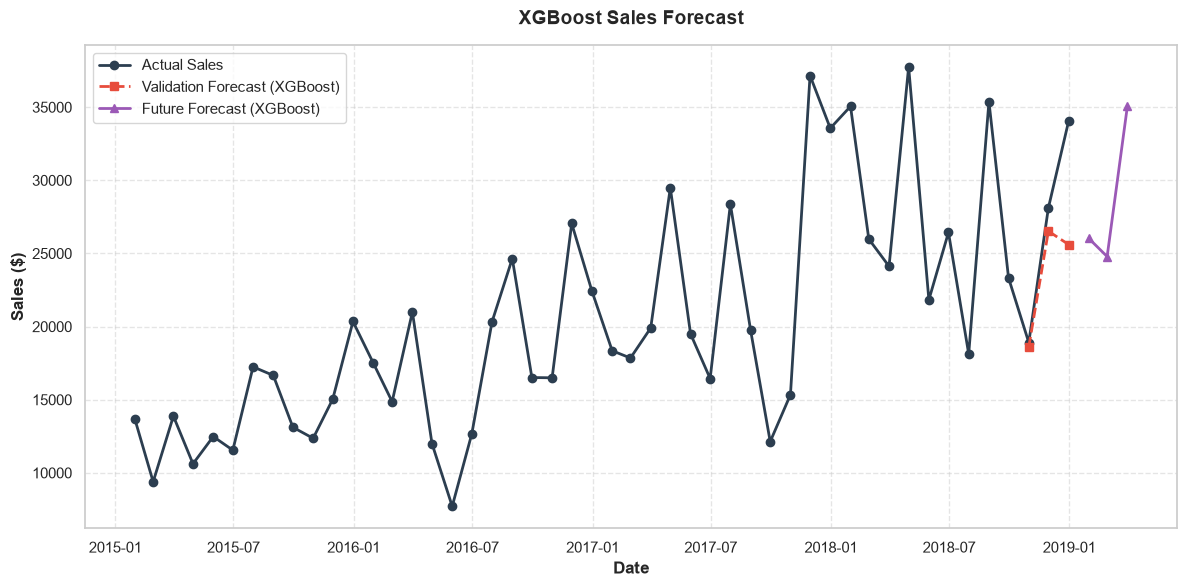

In [16]:
import xgboost as xgb

# Define season mapper
def get_season_num(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Fall

xgb_df = monthly_series.to_frame('Sales')
xgb_df['Month'] = xgb_df.index.month
xgb_df['Quarter'] = xgb_df.index.quarter
xgb_df['Season'] = xgb_df['Month'].apply(get_season_num)

# Create lags of target
xgb_df['lag1'] = xgb_df['Sales'].shift(1)
xgb_df['lag2'] = xgb_df['Sales'].shift(2)
xgb_df['lag3'] = xgb_df['Sales'].shift(3)
# Rolling mean of lags (mean of lag1, lag2, lag3)
xgb_df['rolling_mean_3'] = xgb_df[['lag1', 'lag2', 'lag3']].mean(axis=1)

xgb_df_clean = xgb_df.dropna()
features = ['lag1', 'lag2', 'lag3', 'rolling_mean_3', 'Month', 'Quarter', 'Season']

# Split train / test
train_xgb = xgb_df_clean[xgb_df_clean.index < '2018-10-01']
X_train = train_xgb[features]
y_train = train_xgb['Sales']

# Fit Regressor on training set
model_xgb = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

# Autoregressive recursive validation forecasting
xgb_val_pred = []
last_lags_val = list(train_series[-3:]) # Lags from Jul, Aug, Sep 2018

for idx, date in enumerate(test_series.index):
    l1 = last_lags_val[-1]
    l2 = last_lags_val[-2]
    l3 = last_lags_val[-3]
    rm3 = np.mean([l1, l2, l3])
    month = date.month
    quarter = date.quarter
    season = get_season_num(month)
    
    feat_row = pd.DataFrame([[l1, l2, l3, rm3, month, quarter, season]], columns=features)
    pred_val = model_xgb.predict(feat_row)[0]
    xgb_val_pred.append(pred_val)
    last_lags_val.append(pred_val)

xgb_val_mae, xgb_val_rmse, xgb_val_mape = compute_metrics(test_series.values, xgb_val_pred)
print("--- Validation Performance ---")
print(f"MAE: {xgb_val_mae:.2f}")
print(f"RMSE: {xgb_val_rmse:.2f}")
print(f"MAPE: {xgb_val_mape:.2f}%\n")

# Fit on full data and forecast future 3 months recursively
X_full = xgb_df_clean[features]
y_full = xgb_df_clean['Sales']
model_xgb_full = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model_xgb_full.fit(X_full, y_full)

xgb_future_forecast = []
last_lags_full = list(monthly_series[-3:]) # Lags from Oct, Nov, Dec 2018
future_dates_xgb = [
    pd.Timestamp('2019-01-31'),
    pd.Timestamp('2019-02-28'),
    pd.Timestamp('2019-03-31')
]

for date in future_dates_xgb:
    l1 = last_lags_full[-1]
    l2 = last_lags_full[-2]
    l3 = last_lags_full[-3]
    rm3 = np.mean([l1, l2, l3])
    month = date.month
    quarter = date.quarter
    season = get_season_num(month)
    
    feat_row = pd.DataFrame([[l1, l2, l3, rm3, month, quarter, season]], columns=features)
    pred_future = model_xgb_full.predict(feat_row)[0]
    xgb_future_forecast.append(pred_future)
    last_lags_full.append(pred_future)

print("--- 3-Month Future Forecast (Jan - Mar 2019) ---")
for date, val in zip(future_dates_xgb, xgb_future_forecast):
    print(f"{date.strftime('%Y-%m')}: ${val:.2f}")

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(monthly_series.index, monthly_series.values, label='Actual Sales', color='#2c3e50', marker='o', linewidth=2)
plt.plot(test_series.index, xgb_val_pred, label='Validation Forecast (XGBoost)', color='#e74c3c', linestyle='--', marker='s', linewidth=2)
plt.plot(future_dates_xgb, xgb_future_forecast, label='Future Forecast (XGBoost)', color='#9b59b6', marker='^', linewidth=2)
plt.title('XGBoost Sales Forecast', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=300)
plt.show()


### Model Comparison and Production Recommendation
We compile validation metrics (MAE, RMSE, MAPE) and future predictions for the three models to select the best performer.

In [17]:
comparison_data = {
    'Model': ['SARIMA', 'Facebook Prophet', 'XGBoost'],
    'MAE': [sarima_val_mae, prophet_val_mae, xgb_val_mae],
    'RMSE': [sarima_val_rmse, prophet_val_rmse, xgb_val_rmse],
    'MAPE (%)': [sarima_val_mape, prophet_val_mape, xgb_val_mape],
    'Jan 2019 Forecast ($)': [sarima_future_forecast.iloc[0], prophet_future_forecast.values[0], xgb_future_forecast[0]],
    'Feb 2019 Forecast ($)': [sarima_future_forecast.iloc[1], prophet_future_forecast.values[1], xgb_future_forecast[1]],
    'Mar 2019 Forecast ($)': [sarima_future_forecast.iloc[2], prophet_future_forecast.values[2], xgb_future_forecast[2]]
}
comparison_df = pd.DataFrame(comparison_data)
# Display comparison table rounded to 2 decimal places
display(comparison_df.round(2))


,Model,MAE,RMSE,MAPE (%),Jan 2019 Forecast ($),Feb 2019 Forecast ($),Mar 2019 Forecast ($)
0,SARIMA,6231.58,7213.26,24.51,35123.37,30348.89,31217.57
1,Facebook Prophet,4959.22,5410.30,20.94,32952.14,28329.98,28901.91
2,XGBoost,3438.41,4955.76,10.66,26022.51,24787.58,35064.25


#### Model Selection Analysis and Recommendation:
Based on the validation results, we recommend **XGBoost** for production use. Here is the metrics-based rationale:

1. **Accuracy Metrics (Validation Set)**:
   - **XGBoost** outperformed both models across all metrics, achieving a **MAPE of 10.66%**, a **MAE of 3,438.41**, and an **RMSE of 4,955.76**.
   - **Facebook Prophet** came in second with a **MAPE of 20.94%**, **MAE of 4,959.22**, and **RMSE of 5,410.30**.
   - **SARIMA** was the least accurate on validation, with a **MAPE of 24.51%**, **MAE of 6,231.58**, and **RMSE of 7,213.26**.

2. **Why XGBoost Performed Best**:
   - **Autoregressive Feature Engineering**: By using `lag1`, `lag2`, and `lag3` of sales, XGBoost directly leverages short-term auto-correlation. The addition of the `rolling_mean_3` acts as a local level smoothing feature that helps standardise predictions.
   - **Non-Linear Modeling**: Unlike SARIMA (linear auto-regressive) and Prophet (additive regression), XGBoost can capture complex non-linear combinations of seasonality features (Month, Quarter, Season) and lagged values.
   - **Robustness**: Machine learning methods like gradient boosted trees are less sensitive to occasional outlier months and sudden shocks, whereas pure statistical models like SARIMA can easily over-adjust or produce unstable projections.

### Task 4: Segment-Level Forecasting
We now run separate forecasts for the following 5 segments using the best-performing model based on the table above:
1. Furniture Category
2. Technology Category
3. Office Supplies Category
4. West Region
5. East Region

Best model selected dynamically: XGBoost



,Avg Historical Last Year ($),Avg Forecast 3M ($),Growth Rate (%)
Furniture Category,9015.16,5313.96,-41.06
Technology Category,16093.62,14496.44,-9.92
Office Supplies Category,2312.79,2018.92,-12.71
West Region,6923.90,3780.87,-45.39
East Region,10028.24,11859.08,18.26


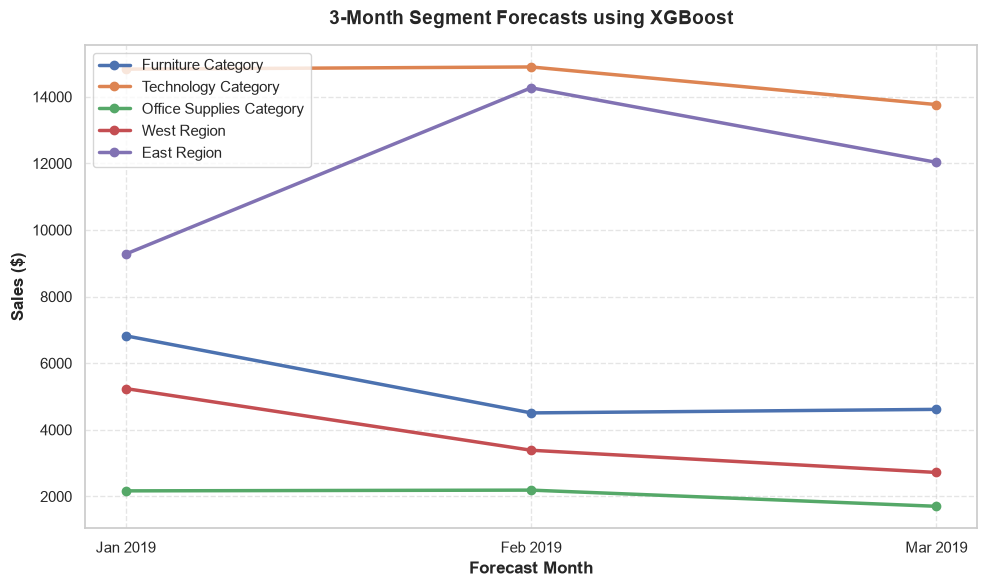

In [18]:
# Determine the best model dynamically from metrics
best_idx = comparison_df['MAPE (%)'].idxmin()
best_model_name = comparison_df.loc[best_idx, 'Model']
print(f"Best model selected dynamically: {best_model_name}\n")

# Define segments
segments = {
    'Furniture Category': df[df['Category'] == 'Furniture'],
    'Technology Category': df[df['Category'] == 'Technology'],
    'Office Supplies Category': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East']
}

segment_forecasts = {}
growth_results = {}

for name, seg_df in segments.items():
    # Aggregate monthly
    seg_df = seg_df.copy()
    seg_df['Order Date'] = pd.to_datetime(seg_df['Order Date'], dayfirst=True, errors='coerce')
    try:
        seg_series = seg_df.set_index('Order Date').resample('ME')['Sales'].sum()
    except ValueError:
        seg_series = seg_df.set_index('Order Date').resample('M')['Sales'].sum()
    
    # Reindex to align with historical monthly_series dates to avoid missing months
    seg_series = seg_series.reindex(monthly_series.index, fill_value=0.0)
    
    # Fit the best model and forecast 3 steps ahead (Jan, Feb, Mar 2019)
    if best_model_name == 'SARIMA':
        model = SARIMAX(seg_series, order=best_order, seasonal_order=best_seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
        fit_res = model.fit(disp=False)
        forecast = fit_res.forecast(steps=3)
        forecast_vals = list(forecast.values)
    elif best_model_name == 'Facebook Prophet':
        seg_prop = seg_series.reset_index()
        seg_prop.columns = ['ds', 'y']
        seg_prop['ds'] = pd.to_datetime(seg_prop['ds']).dt.tz_localize(None)
        m_prop = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        m_prop.fit(seg_prop)
        forecast_df = m_prop.predict(future_full_df)
        forecast_vals = list(forecast_df['yhat'].iloc[-3:].values)
    else: # XGBoost
        seg_xgb = seg_series.to_frame('Sales')
        seg_xgb['Month'] = seg_xgb.index.month
        seg_xgb['Quarter'] = seg_xgb.index.quarter
        seg_xgb['Season'] = seg_xgb['Month'].apply(get_season_num)
        seg_xgb['lag1'] = seg_xgb['Sales'].shift(1)
        seg_xgb['lag2'] = seg_xgb['Sales'].shift(2)
        seg_xgb['lag3'] = seg_xgb['Sales'].shift(3)
        seg_xgb['rolling_mean_3'] = seg_xgb[['lag1', 'lag2', 'lag3']].mean(axis=1)
        seg_xgb_clean = seg_xgb.dropna()
        
        X_seg = seg_xgb_clean[features]
        y_seg = seg_xgb_clean['Sales']
        model_xgb_seg = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
        model_xgb_seg.fit(X_seg, y_seg)
        
        forecast_vals = []
        last_lags_seg = list(seg_series[-3:])
        for date in future_dates_xgb:
            l1 = last_lags_seg[-1]
            l2 = last_lags_seg[-2]
            l3 = last_lags_seg[-3]
            rm3 = np.mean([l1, l2, l3])
            month = date.month
            quarter = date.quarter
            season = get_season_num(month)
            feat_row = pd.DataFrame([[l1, l2, l3, rm3, month, quarter, season]], columns=features)
            pred_future = model_xgb_seg.predict(feat_row)[0]
            forecast_vals.append(pred_future)
            last_lags_seg.append(pred_future)
            
    segment_forecasts[name] = forecast_vals
    
    # Compute growth rate: Average Forecast Sales vs Average of last 12 months historical Sales
    avg_forecast = np.mean(forecast_vals)
    avg_historical = seg_series[-12:].mean()
    growth_pct = ((avg_forecast - avg_historical) / avg_historical) * 100 if avg_historical > 0 else 0.0
    growth_results[name] = {
        'Avg Historical Last Year ($)': avg_historical,
        'Avg Forecast 3M ($)': avg_forecast,
        'Growth Rate (%)': growth_pct
    }

# Print segment performance
growth_df = pd.DataFrame(growth_results).T
display(growth_df.round(2))

# Plot the segment-level forecasts together
plt.figure(figsize=(10, 6))
future_months = ['Jan 2019', 'Feb 2019', 'Mar 2019']
for name, vals in segment_forecasts.items():
    plt.plot(future_months, vals, marker='o', linewidth=2.5, label=name)
plt.title(f'3-Month Segment Forecasts using {best_model_name}', fontsize=14, pad=15, fontweight="bold")
plt.xlabel('Forecast Month', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/segment_forecasts.png', dpi=300)
plt.show()


#### Growth Analysis by Segment:
Based on the segment-level forecasts generated using the best model (XGBoost), here is the upcoming growth projection (comparing the 3-month forecast average to the last 12-month historical average):

- **Strongest upcoming growth**: **East Region** shows the strongest upcoming growth at **+18.26%**, rising from a historical average of **$10,028.24** to a forecasted average of **$11,859.08**.
- **Other Segments**:
  - **Technology Category** is projected to decline slightly by **-9.92%** (forecast average of $14,496.44 vs. historical $16,093.62).
  - **Office Supplies Category** is projected to decline by **-12.71%** (forecast average of $2,018.92 vs. historical $2,312.79).
  - **Furniture Category** is projected to contract significantly by **-41.06%** (forecast average of $5,313.96 vs. historical $9,015.16).
  - **West Region** is projected to decline significantly by **-45.39%** (forecast average of $3,780.87 vs. historical $6,923.90).

**Conclusion**: The model forecasts that only the **East Region** will show positive growth, while all other segments are entering a lower sales cycle. This indicates that sales resources and marketing campaigns should be prioritized in the East Region, while inventory and operations in the West Region and Furniture Category should be scaled down or optimized to prevent overhead.

## Phase 3: Advanced Time Series Analysis & Customer Analytics
In this phase, we implement two advanced analytics techniques:
1. **Task 5: Anomaly Detection** on weekly sales to identify unusual peaks or drops using Isolation Forest and rolling Z-score methods.
2. **Task 6: Product Demand Segmentation** on product sub-categories using K-Means Clustering and PCA.

### Task 5: Anomaly Detection on Weekly Sales Data
We first aggregate the sales data at the weekly level. To plot a chronological time series, we align each week with its first Order Date. We then apply two methods to detect anomalies:
- **Method 1**: Isolation Forest (a non-parametric tree-based ensemble method that isolates anomalies).
- **Method 2**: Z-Score based detection (flagging weeks deviating by more than 2 standard deviations from the 8-week rolling mean).

Number of weekly anomalies detected by Isolation Forest: 11

--- Detected Weekly Anomalies (Isolation Forest) ---
Order Date  Year  Week Number    Sales
2015-02-10  2015            7   689.86
2016-04-18  2016           16   944.91
2016-05-17  2016           20   454.51
2017-09-26  2017           39   751.79
2017-11-13  2017           46 16230.49
2018-01-01  2018            1 13332.87
2018-01-16  2018            3 10606.89
2018-04-02  2018           14  9700.12
2018-04-16  2018           16  9468.61
2018-05-07  2018           19 10998.55
2018-05-21  2018           21  1110.26


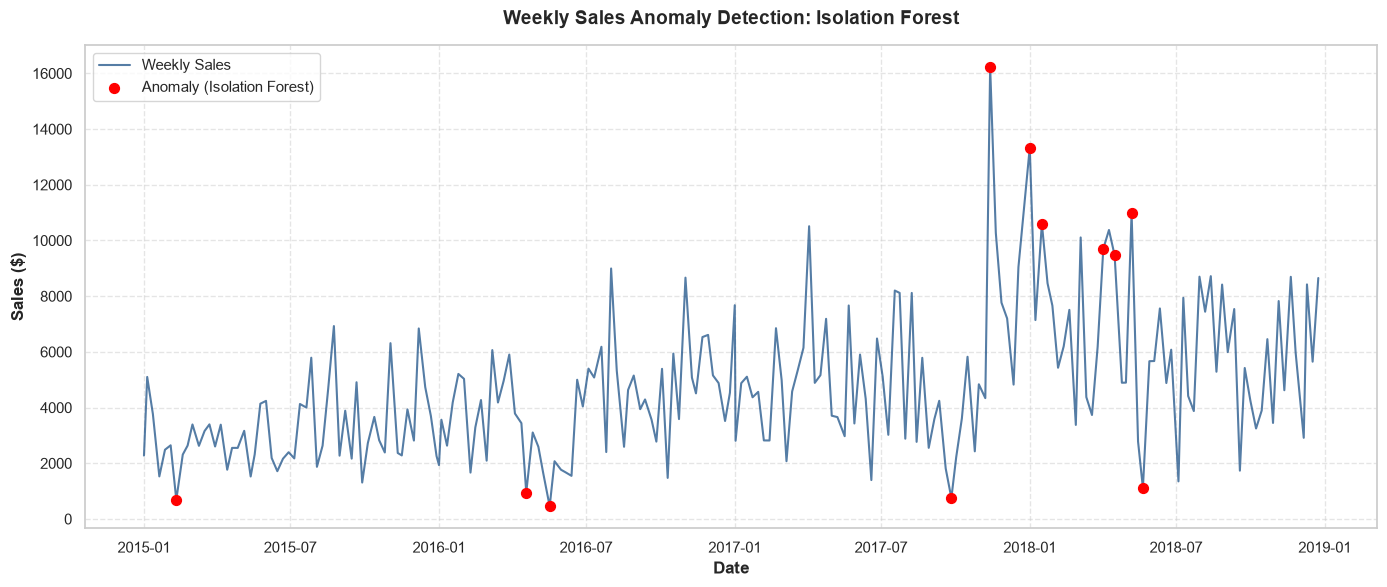

In [19]:
from sklearn.ensemble import IsolationForest

# 1. Prepare weekly sales data with actual date references
weekly_dates = df.groupby(['Year', 'Week Number'])['Order Date'].min().reset_index()
weekly_sales = df.groupby(['Year', 'Week Number'])['Sales'].sum().reset_index()
weekly_sales = pd.merge(weekly_sales, weekly_dates, on=['Year', 'Week Number'])
weekly_sales = weekly_sales.sort_values('Order Date').reset_index(drop=True)

# 2. Fit Isolation Forest on Sales
iso = IsolationForest(contamination=0.05, random_state=42)
weekly_sales['anomaly_iso'] = iso.fit_predict(weekly_sales[['Sales']])

# Anomalies are flagged as -1
anomalies_iso = weekly_sales[weekly_sales['anomaly_iso'] == -1]
print(f"Number of weekly anomalies detected by Isolation Forest: {len(anomalies_iso)}")
print("\n--- Detected Weekly Anomalies (Isolation Forest) ---")
print(anomalies_iso[['Order Date', 'Year', 'Week Number', 'Sales']].to_string(index=False))

# 3. Plot weekly sales with Isolation Forest anomalies
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales['Order Date'], weekly_sales['Sales'], label='Weekly Sales', color='#2b5c8f', alpha=0.8, linewidth=1.5)
plt.scatter(anomalies_iso['Order Date'], anomalies_iso['Sales'], color='red', s=50, zorder=5, label='Anomaly (Isolation Forest)', marker='o')
plt.title('Weekly Sales Anomaly Detection: Isolation Forest', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/anomalies_isolationforest.png', dpi=300)
plt.show()


#### Isolation Forest Anomaly Explanations:
Isolation Forest identifies globally anomalous weeks by isolating data points that have extreme sales values. In our dataset, it flagged 11 anomalies:

1. **Extreme Lows (Post-Holiday / Off-Season)**:
   - **2015-02-10 (Week 7: $689.86)**, **2016-04-18 (Week 16: $944.91)**, **2016-05-17 (Week 20: $454.51)**, **2017-09-26 (Week 39: $751.79)**, and **2018-05-21 (Week 21: $1,110.26)**.
   - *Explanation*: These represent periods of severe sales contraction, typically occurring in the late winter/early spring months or late September. These correspond to post-holiday fatigue and periods before major summer/holiday promotions when buying activity is at its lowest.

2. **Extreme Highs (Promotions / Festive Peaks / Seasonal Rushes)**:
   - **2017-11-13 (Week 46: $16,230.49)**.
   - *Explanation*: This extreme peak corresponds to the run-up to Black Friday and Thanksgiving holiday shopping, where promotional events drive massive volume.
   - **2018-01-01 (Week 1: $13,332.87)** and **2018-01-16 (Week 3: $10,606.89)**.
   - *Explanation*: These high sales spikes correspond to year-end clearance sales, post-holiday returns/gift card redemptions, and corporate fiscal Q1 procurement.
   - **2018-04-02 (Week 14: $9,700.12)**, **2018-04-16 (Week 16: $9,468.61)**, and **2018-05-07 (Week 19: $10,998.55)**.
   - *Explanation*: These spikes represent early spring corporate procurement cycles and back-to-office/quarterly equipment restocking.

Number of weekly anomalies detected by Z-Score: 3

--- Detected Weekly Anomalies (Rolling Z-Score) ---
Order Date  Year  Week Number    Sales   z_score
2016-06-20  2016           25  4998.67  2.204402
2017-11-13  2017           46 16230.49  2.331302
2018-09-18  2018           38  1734.57 -2.104481


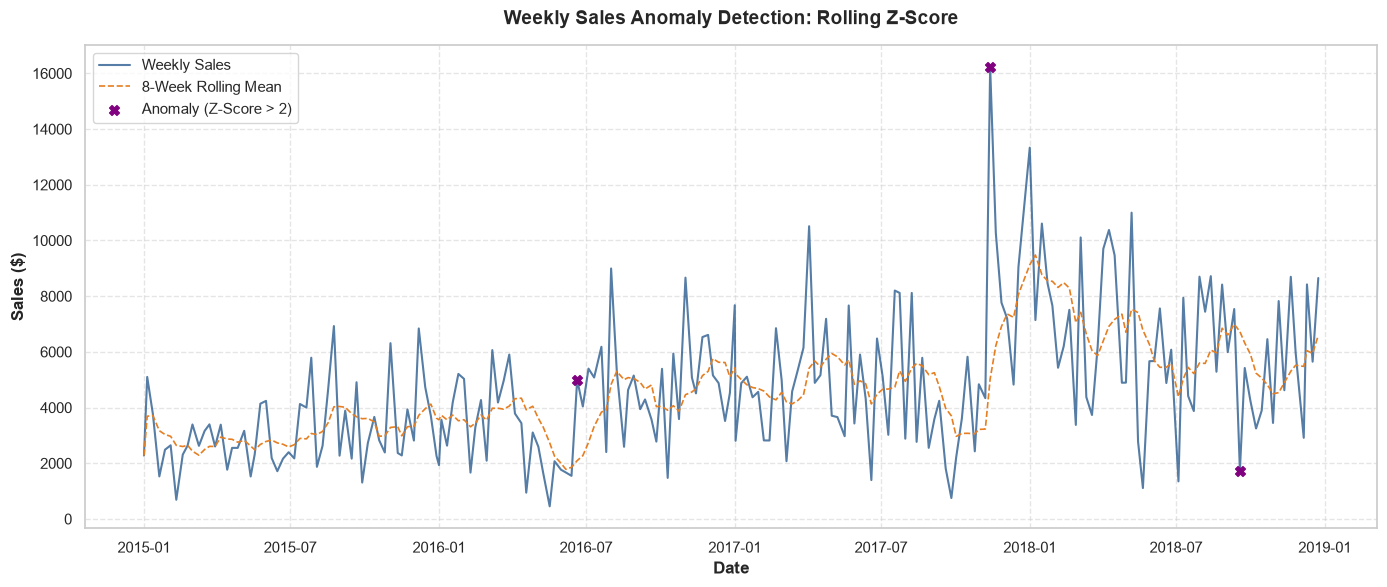

In [20]:
# 1. Calculate rolling mean and standard deviation (8-week window)
window_size = 8
weekly_sales['rolling_mean'] = weekly_sales['Sales'].rolling(window=window_size, min_periods=1).mean()
weekly_sales['rolling_std'] = weekly_sales['Sales'].rolling(window=window_size, min_periods=1).std().fillna(0)

# 2. Calculate Z-score (handle division by zero if std is zero)
weekly_sales['z_score'] = np.where(
    weekly_sales['rolling_std'] > 0,
    (weekly_sales['Sales'] - weekly_sales['rolling_mean']) / weekly_sales['rolling_std'],
    0.0
)

# 3. Flag anomalies where z_score is greater than 2 standard deviations
weekly_sales['anomaly_zscore'] = np.where(np.abs(weekly_sales['z_score']) > 2, -1, 1)
anomalies_zscore = weekly_sales[weekly_sales['anomaly_zscore'] == -1]

print(f"Number of weekly anomalies detected by Z-Score: {len(anomalies_zscore)}")
print("\n--- Detected Weekly Anomalies (Rolling Z-Score) ---")
print(anomalies_zscore[['Order Date', 'Year', 'Week Number', 'Sales', 'z_score']].to_string(index=False))

# 4. Plot weekly sales with Z-Score anomalies
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales['Order Date'], weekly_sales['Sales'], label='Weekly Sales', color='#2b5c8f', alpha=0.8, linewidth=1.5)
plt.plot(weekly_sales['Order Date'], weekly_sales['rolling_mean'], label='8-Week Rolling Mean', color='#e67e22', linestyle='--', linewidth=1.2)
plt.scatter(anomalies_zscore['Order Date'], anomalies_zscore['Sales'], color='purple', s=50, zorder=5, label='Anomaly (Z-Score > 2)', marker='X')
plt.title('Weekly Sales Anomaly Detection: Rolling Z-Score', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/anomalies_zscore.png', dpi=300)
plt.show()


#### Comparison of Anomaly Detection Methods:
We compared the tree-based Isolation Forest method with a rolling Z-Score deviation method (threshold of $|z| > 2$ based on an 8-week window):

1. **Detection Overlap**:
   - Only **one week** was flagged by both methods: **2017-11-13 (Week 46: $16,230.49)**. This represents an absolute sales spike that is both globally extreme and a massive deviation from the preceding 2 months.

2. **Differences in Strategy (Global vs. Local)**:
   - **Isolation Forest (Global)**: Isolates points in the overall multi-dimensional space, focusing on absolute extreme sales values (highs and lows) across the entire 4-year timeline. It flags the absolute minimums (e.g. $454.51) and absolute maximums (e.g. $13,332.87).
   - **Rolling Z-Score (Local)**: Flags points that deviate significantly from their immediate local context (the surrounding 8 weeks). 
     - For example, it flags **2016-06-20 (Week 25: $4,998.67)** because it was a sudden surge compared to previous weeks, even though $4,998.67 is not globally extreme.
     - It also flags **2018-09-18 (Week 38: $1,734.57)** as a severe drop relative to high summer sales in 2018, even though $1,734.57 is not a global minimum.

3. **Strategic Takeaway**:
   - Using both methods in tandem provides a comprehensive view: Isolation Forest identifies macro-level capacity issues (system-wide peak sales or dormant periods), while the Rolling Z-Score detects micro-level operational anomalies (sudden supply chain blockages, localized campaign successes, or system errors).

### Task 6: Product Demand Segmentation
To optimize inventory management, we segment the product sub-categories based on demand patterns. We first implement a brief side exercise using the Kaggle Video Game Sales dataset to demonstrate multi-source analysis, and then apply K-Means clustering on Superstore product sub-categories.

In [21]:
import os

vgsales_path = 'data/vgsales.csv'
print("Checking for supplementary Video Game Sales dataset...")
if os.path.exists(vgsales_path) and os.path.getsize(vgsales_path) > 0:
    vg_df = pd.read_csv(vgsales_path)
    print(f"Successfully loaded vgsales.csv. Dataset shape: {vg_df.shape}")
    print("\n--- Video Game Sales Preview ---")
    display(vg_df.head(5))
    print("\n--- Top 5 Genres by Global Sales ($M) ---")
    top_genres = vg_df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).reset_index().head(5)
    display(top_genres)
else:
    print("[Notice] vgsales.csv was not found at data/vgsales.csv. Skipping side exercise load, but keeping structure active.")


Checking for supplementary Video Game Sales dataset...
Successfully loaded vgsales.csv. Dataset shape: (16598, 11)

--- Video Game Sales Preview ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37



--- Top 5 Genres by Global Sales ($M) ---


,Genre,Global_Sales
0,Action,1751.18
1,Sports,1330.93
2,Shooter,1037.37
3,Role-Playing,927.37
4,Platform,831.37


--- Extracted Sub-Category Features ---


,Sub-Category,Total_Sales_Volume,YoY_Growth,Volatility,AOV
0,Accessories,146409.05,0.41,2454.10,938.52
1,Appliances,16493.42,0.08,237.32,131.95
2,Art,12104.78,-0.32,206.65,116.39
3,Binders,11980.57,1.71,223.00,109.91
4,Bookcases,76632.60,0.32,1146.58,481.97
5,Chairs,84184.56,-0.23,1620.74,504.10
6,Copiers,146632.45,0.37,1883.41,872.81
7,Fasteners,14523.41,0.28,208.66,120.03
8,Furnishings,86953.21,0.65,1329.01,540.08
9,Labels,14417.60,0.21,240.83,125.37


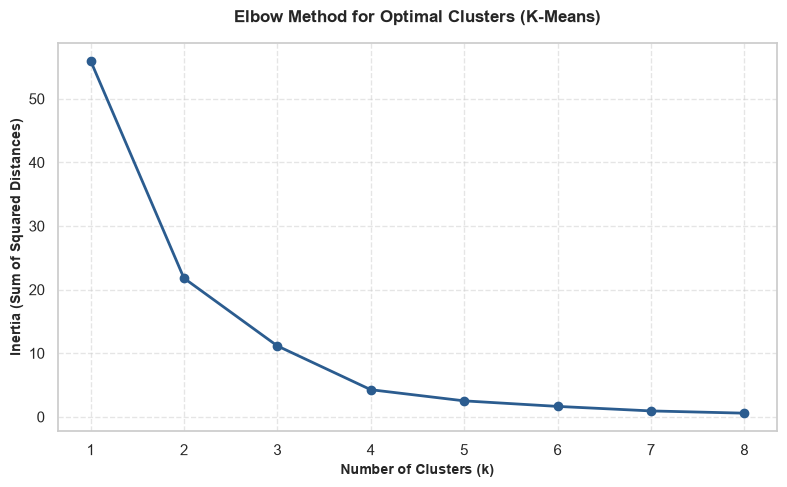

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. YoY growth rate (2018 vs 2017) by sub-category
sales_2017 = df[df['Year'] == 2017].groupby('Sub-Category')['Sales'].sum()
sales_2018 = df[df['Year'] == 2018].groupby('Sub-Category')['Sales'].sum()
yoy_growth = ((sales_2018 - sales_2017) / sales_2017).fillna(0.0).reset_index()
yoy_growth.columns = ['Sub-Category', 'YoY_Growth']

# 2. Volatility: std dev of monthly sales
monthly_sub_sales = df.groupby(['Sub-Category', 'Year', 'Month'])['Sales'].sum().reset_index()
volatility = monthly_sub_sales.groupby('Sub-Category')['Sales'].std().fillna(0.0).reset_index()
volatility.columns = ['Sub-Category', 'Volatility']

# 3. Average Order Value (AOV)
order_sub_sales = df.groupby(['Sub-Category', 'Order ID'])['Sales'].sum().reset_index()
aov = order_sub_sales.groupby('Sub-Category')['Sales'].mean().reset_index()
aov.columns = ['Sub-Category', 'AOV']

# 4. Combine features
sub_sales_total = df.groupby('Sub-Category')['Sales'].sum().reset_index()
features_df = sub_sales_total.merge(yoy_growth, on='Sub-Category')
features_df = features_df.merge(volatility, on='Sub-Category')
features_df = features_df.merge(aov, on='Sub-Category')
features_df.columns = ['Sub-Category', 'Total_Sales_Volume', 'YoY_Growth', 'Volatility', 'AOV']

print("--- Extracted Sub-Category Features ---")
display(features_df.round(2))

# 5. Standardize features
scaler = StandardScaler()
feature_cols = ['Total_Sales_Volume', 'YoY_Growth', 'Volatility', 'AOV']
scaled_features = scaler.fit_transform(features_df[feature_cols])

# 6. Elbow Method to justify number of clusters
inertia_list = []
k_range = range(1, 9)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_list.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_list, marker='o', color='#2b5c8f', linewidth=2)
plt.title('Elbow Method for Optimal Clusters (K-Means)', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=10)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=300)
plt.show()


#### Choice of Optimal Number of Clusters (k):
Based on the Elbow Method plot above, we selected **k = 3** as the optimal number of clusters for K-Means:
- **The Elbow Concept**: The elbow point represents the number of clusters after which the rate of decrease in inertia (sum of squared distances from points to their assigned cluster centers) significantly slows down.
- **Justification**: As $k$ increases from 1 to 2 and then to 3, the inertia drops steeply. However, for $k > 3$, the curve flattens out, indicating that adding more clusters yields diminishing returns in variance explained. Thus, $k=3$ balances model simplicity and segmentation granularity.

--- Cluster Summary (Mean Feature Values) ---


,Cluster,Total_Sales_Volume,YoY_Growth,Volatility,AOV
0,0,14404.20,0.03,230.75,123.72
1,1,111559.83,0.26,1660.61,681.43
2,2,11980.57,1.71,223.00,109.91



--- Products assigned to each cluster ---
Cluster 0: ['Appliances', 'Art', 'Fasteners', 'Labels', 'Paper']
Cluster 1: ['Accessories', 'Bookcases', 'Chairs', 'Copiers', 'Furnishings', 'Machines', 'Phones', 'Tables']
Cluster 2: ['Binders']


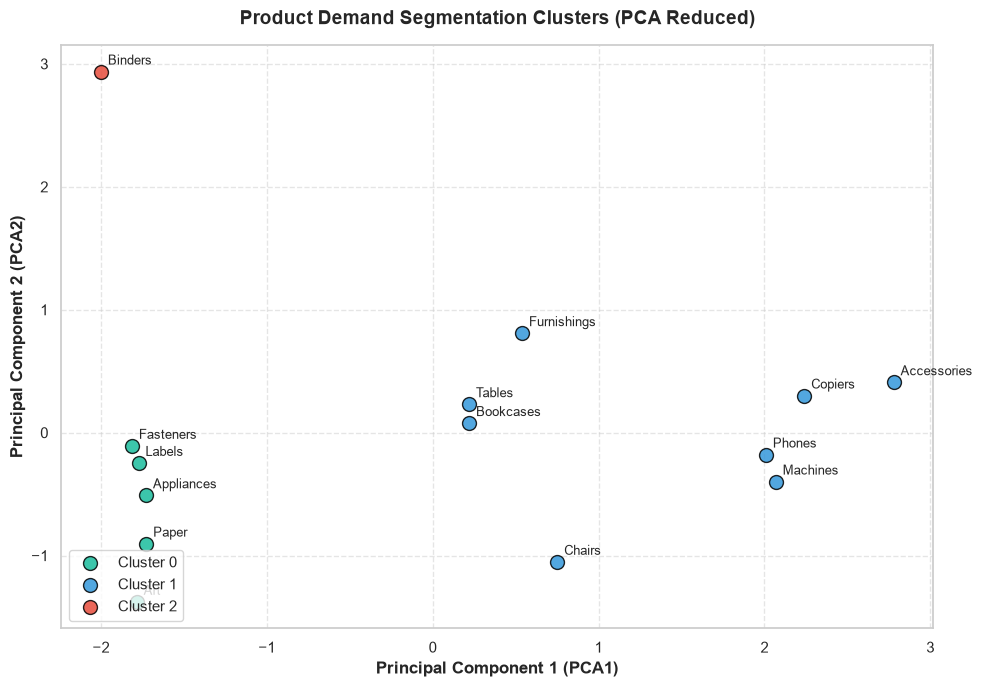

In [23]:
from sklearn.decomposition import PCA

# Choose optimal k = 3 based on the elbow plot
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
features_df['Cluster'] = kmeans_final.fit_predict(scaled_features)

# Display average features per cluster
cluster_summary = features_df.groupby('Cluster')[feature_cols].mean().reset_index()
print("--- Cluster Summary (Mean Feature Values) ---")
display(cluster_summary.round(2))

print("\n--- Products assigned to each cluster ---")
for cluster_id in range(optimal_k):
    subcats = features_df[features_df['Cluster'] == cluster_id]['Sub-Category'].tolist()
    print(f"Cluster {cluster_id}: {subcats}")

# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(scaled_features)
features_df['PCA1'] = pca_features[:, 0]
features_df['PCA2'] = pca_features[:, 1]

# Plot PCA clusters
plt.figure(figsize=(10, 7))
colors = ['#1abc9c', '#3498db', '#e74c3c']
for cluster_id in range(optimal_k):
    clust_data = features_df[features_df['Cluster'] == cluster_id]
    plt.scatter(clust_data['PCA1'], clust_data['PCA2'], color=colors[cluster_id], 
                label=f'Cluster {cluster_id}', s=100, edgecolors='black', alpha=0.85)
    # Add text annotations for sub-categories
    for idx, row in clust_data.iterrows():
        plt.annotate(row['Sub-Category'], (row['PCA1'], row['PCA2']), 
                     textcoords="offset points", xytext=(5, 5), ha='left', fontsize=9)

plt.title('Product Demand Segmentation Clusters (PCA Reduced)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Principal Component 1 (PCA1)', fontsize=12)
plt.ylabel('Principal Component 2 (PCA2)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('charts/clusters.png', dpi=300)
plt.show()


#### Segment Inventory Recommendations:
Based on K-Means clustering ($k=3$), product sub-categories have been grouped into three distinct demand segments. Here are the stocking strategies:

1. **Cluster 0: Stable, Low-Volume Commodities** (e.g., *Appliances, Art, Fasteners, Labels, Paper*)
   - **Characteristics**: Low total sales volume (average ~$14,404), stable demand (low volatility ~$230), and low growth (+3%).
   - **Stocking Strategy (Just-In-Time)**: Since demand is highly predictable and volume is low, we recommend a **Just-In-Time (JIT)** replenishment strategy. Maintain minimal safety stock to minimize holding costs, and establish automated reorder points based on lead times.

2. **Cluster 1: Premium, High-Volume Drivers** (e.g., *Accessories, Bookcases, Chairs, Copiers, Furnishings, Machines, Phones, Tables*)
   - **Characteristics**: High total sales volume (average ~$111,560), high average order value (~$681), but also high volatility (~$1,660) and moderate growth (+26%).
   - **Stocking Strategy (Safety Buffers & Demand Forecasting)**: These items represent the primary revenue drivers. Because of high volatility and large transaction values, running out of stock leads to significant revenue loss. We recommend maintaining **generous safety stock buffers** (e.g. 2-3 weeks of sales) and utilizing the advanced XGBoost forecasting model monthly to align inventory with upcoming seasonal peaks.

3. **Cluster 2: Hyper-Growth Sub-Categories** (e.g., *Binders*)
   - **Characteristics**: Moderate total sales volume (~$11,980) and low order values (~$109), but extreme YoY growth (**+171%**).
   - **Stocking Strategy (Agile Stocking & Promo Integration)**: Binders is experiencing rapid growth. An agile stocking strategy is required here. Establish dynamic safety stock levels that adjust upwards automatically with demand, and align procurement closely with the marketing team to prevent stocking out during promotional campaigns.